---
title: "Mineria de procesos"
format:
  html:
    code-fold: false
---

In [1]:
#| echo: false
import pandas as pd
import pm4py
import networkx as nx
import os
df =  pd.read_parquet('..\data\logs.parquet')

La minería de procesos (*Process Mining*) es una técnica que se aplica en ciencia de
datos y análisis de eventos para descubrir, analizar y mejorar procesos de los eventos generados
por la aplicación web. Estos registros (*event logs*) contienen información de las actividades
realizadas en un proceso, cuándo ocurrieron y en qué orden.
Existen tres tipos principales de minería de procesos:

- **Descubrimiento de procesos:** Genera un modelo a partir de un event log, sin necesidad
de un modelo previo. Se usan algoritmo como Heuristic Miner, Alpha Miner o Inductive
Miner , para construir un diagrama que representa la secuencia de eventos, decisiones
y repeticiones en los registros reales.

- **Verificación de conformidad:** Compara un modelo de proceso existente con el comportamiento registrado en los logs de eventos. Sirve para encontrar discrepancias entre
el resultado esperado y el real.

- **Mejora de procesos:** Enriquece un modelo existente con información adicional a partir
de datos reales.

## Preparar datos
En este análisis se va a seguir un descubrimiento de procesos aplicando el algoritmo Heuristic
Miner. Antes de ello, es necesario preparar un conjunto de datos válido para crear un event
log.

In [2]:
df = df.sort_values(['Usuario', 'Fecha']) 

df['is_login'] = df['Evento'] == 'LOGIN'

df['session_number'] = df.groupby('Usuario')['is_login'].cumsum()

df['case_id'] = df['Usuario'].astype(str) + '_sesion_' + df['session_number'].astype(str)

df = df[df['Usuario'] != '#0 - null']

df = df[~df['case_id'].str.contains('sesion_0', na=False)]

df = df[['case_id', 'Evento', 'Fecha']]

df = df.rename(columns={
    'Evento': 'concept:name',
    'Fecha': 'time:timestamp',
    'case_id': 'case:concept:name'
})

event_log = pm4py.format_dataframe(df, 
                                 case_id='case:concept:name',
                                 activity_key='concept:name',
                                 timestamp_key='time:timestamp')


In [3]:
event_log.tail(5)

,case:concept:name,concept:name,time:timestamp,@@index,@@case_index
1997229,susana_sesion_99,CARGAR_DISENO,2025-02-28 12:39:57+00:00,1997229,152446
1997230,susana_sesion_99,AÑADIR_PIEZA,2025-02-28 12:41:23+00:00,1997230,152446
1997231,susana_sesion_99,DESCONEXION,2025-02-28 13:42:37+00:00,1997231,152446
1997232,susana_sesion_99,LOGOUT,2025-02-28 13:42:37+00:00,1997232,152446
1997233,susana_sesion_99,DURACION,2025-02-28 13:42:37+00:00,1997233,152446


## Algoritmo Heuristic Miner

El Heuristic Miner es un algoritmo diseñado para descubrir modelos de procesos a partir de
registros reales de eventos. Se basa en frecuencias y dependencias entre actividades observadas, lo que lo hace más robusto frente al ruido. Usa reglas heurísticas para construir un modelo
que refleje la conducta predominante.

El Flexible Heuristic Miner es una mejora propuesta por Medeiros, Weijters y van der Aalst. Fue diseñada para eliminar algunas limitaciones del algoritmo anterior, y nos permite
ajustar parámetros como la dependencia mínima entre actividades, la detección de estructuras
paralelas y la sensibilidad ante bucles.

- *dependency_threshod*=0.7: Umbral mínimo para aceptar una relación de dependencia entre dos actividades. Cuanto más alto, más estricta es la conexión.

- *and_threshold*=0.7: Nivel mínimo de confianza para detectar divisiones de tipo AND
(actividades concurrente).

- *loop_two_threshold*=0.3: Controla la detección de bucles simples entres dos eventos, un
valor más bajo permite más bucles.

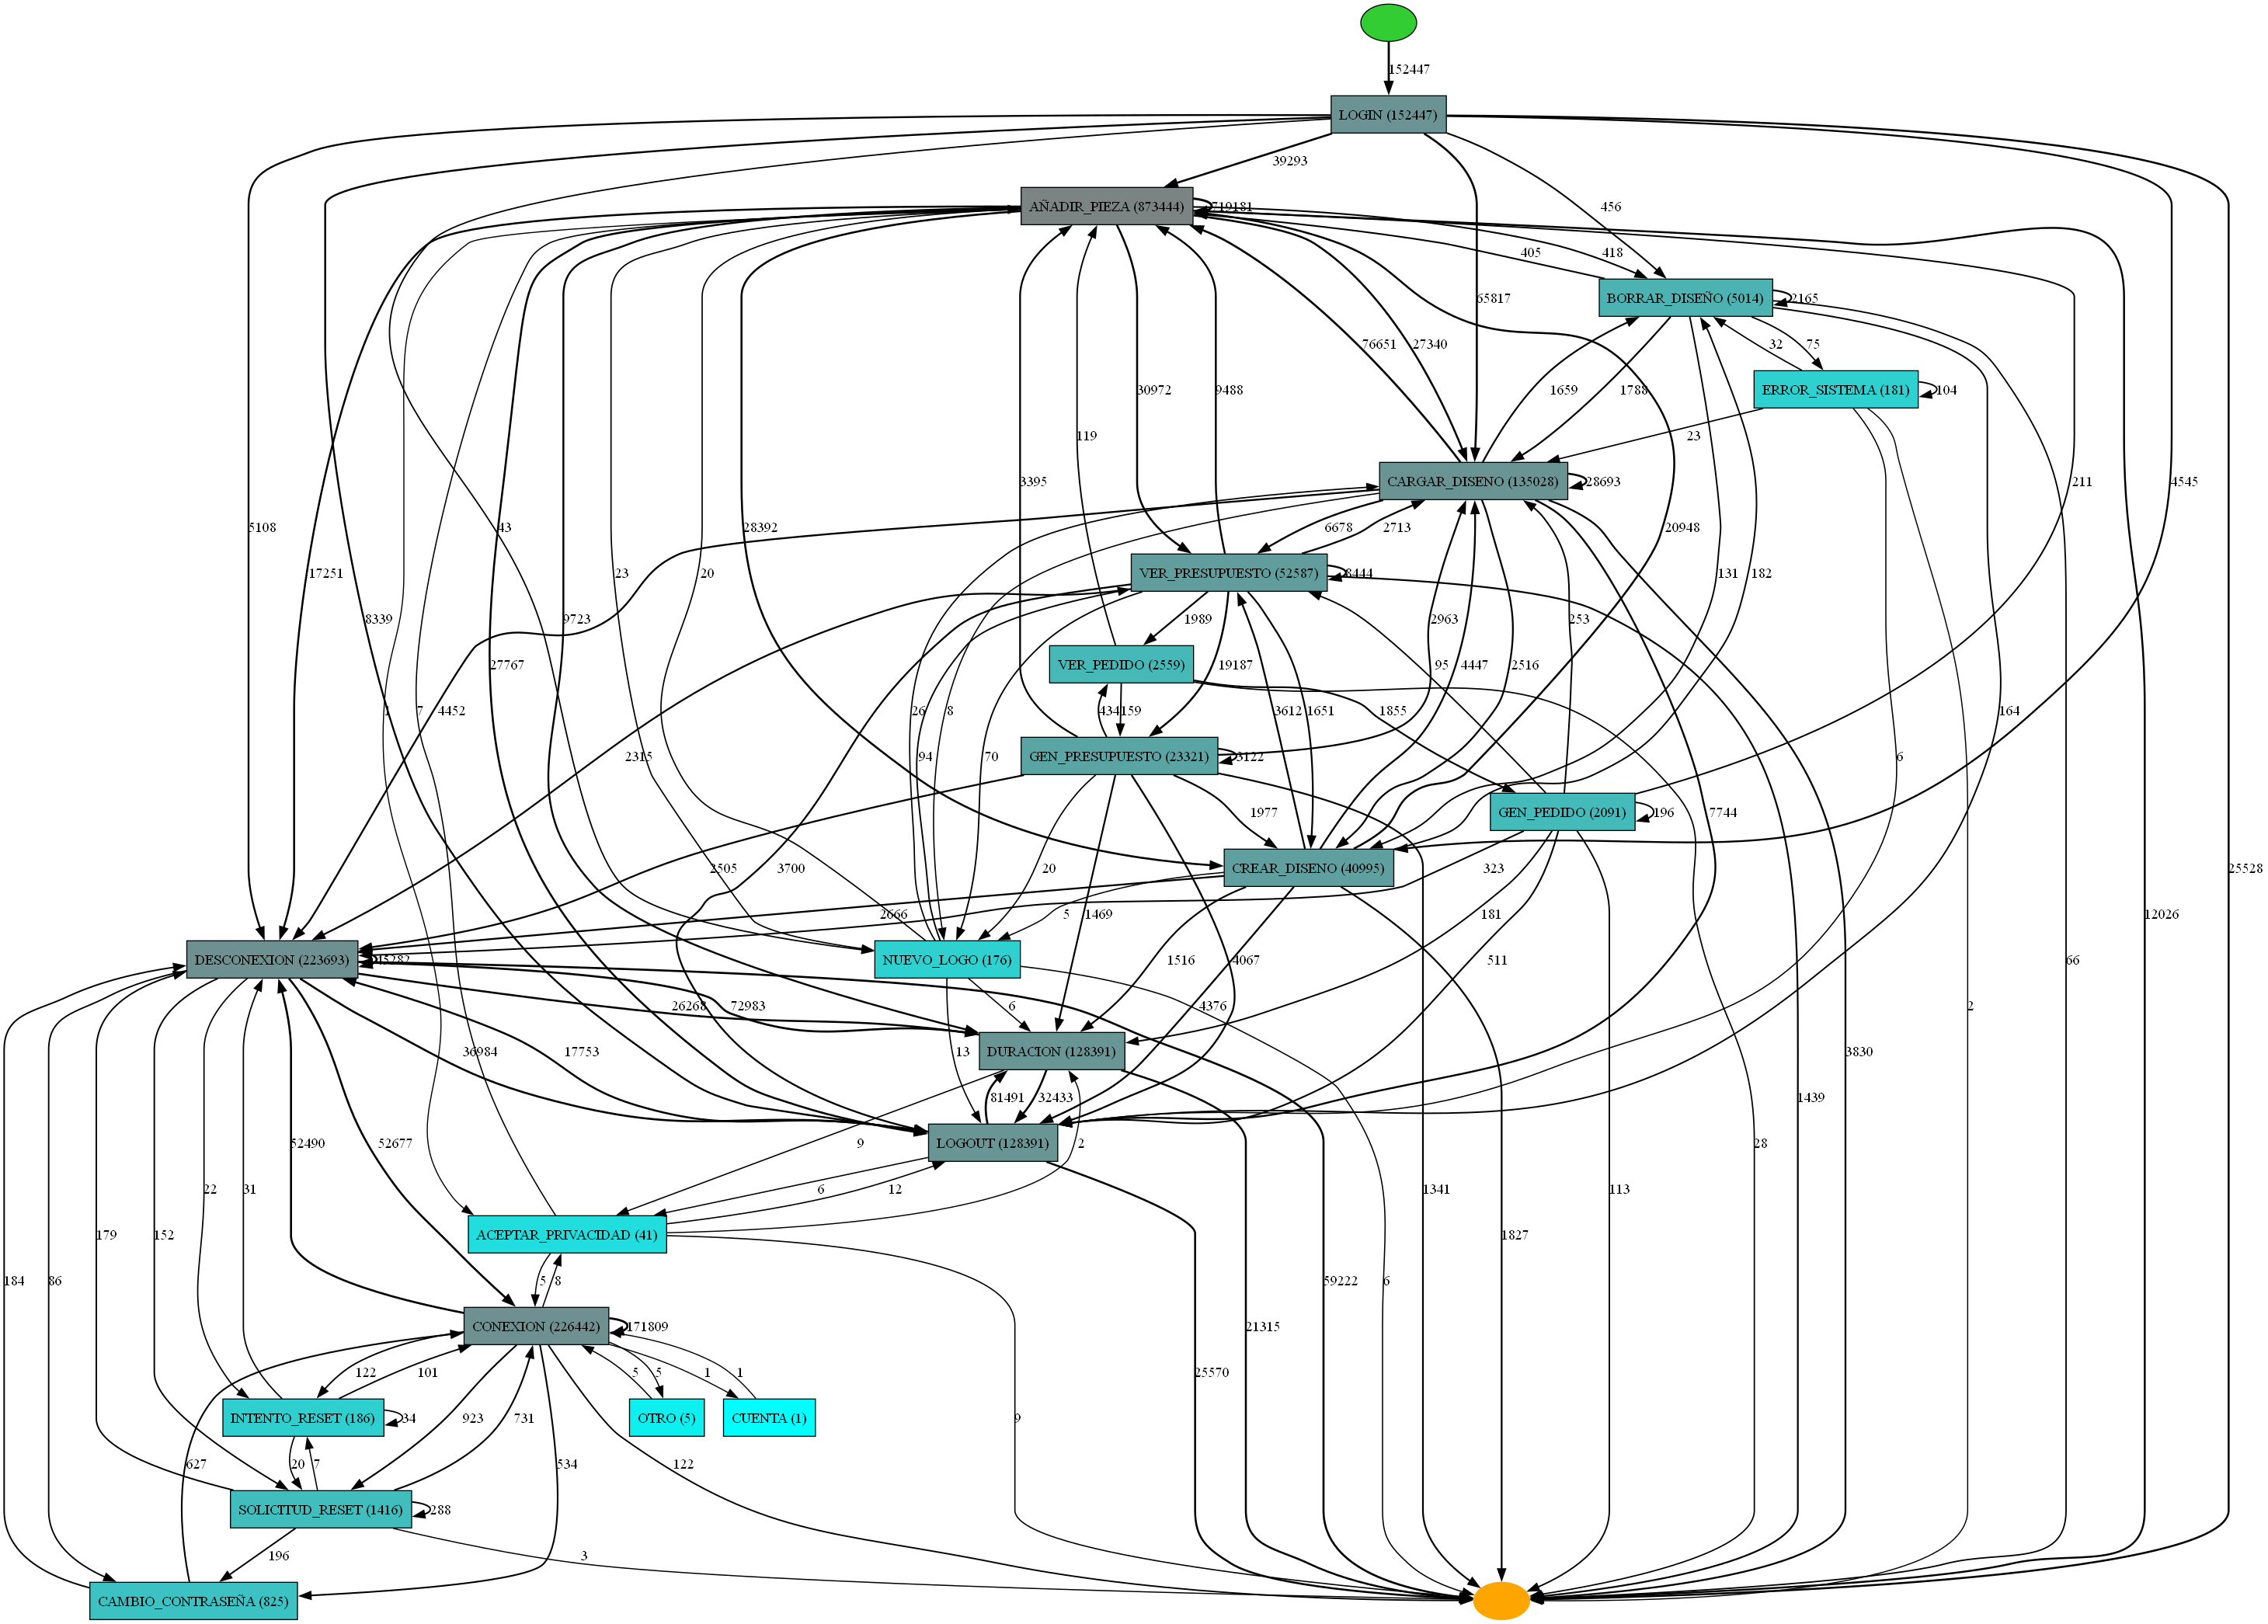

In [5]:
mapa = pm4py.discover_heuristics_net(event_log,dependency_threshold = 0.7, and_threshold = 0.7, loop_two_threshold = 0.3)
pm4py.view_heuristics_net(mapa) 

In [32]:
G = nx.DiGraph([
    (src, tgt, {'weight': freq})
    for src, targets in mapa.dfg_matrix.items()
    for tgt, freq in targets.items()
])
print("Nodos con mayor grado de entrada:")
df_in = pd.DataFrame(G.in_degree, columns=["Actividad", "GradoEntrada"])
df_in = df_in.sort_values(by="GradoEntrada", ascending=False, ignore_index=True)
df_in.head(10)

Nodos con mayor grado de entrada:


,Actividad,GradoEntrada
0,DESCONEXION,15
1,LOGOUT,13
2,AÑADIR_PIEZA,11
3,CARGAR_DISENO,10
4,ACEPTAR_PRIVACIDAD,8
5,CONEXION,8
6,DURACION,8
7,VER_PRESUPUESTO,7
8,CREAR_DISENO,6
9,NUEVO_LOGO,6


In [11]:
print("Nodos con mayor grado de salida:")
df_out = pd.DataFrame(G.out_degree, columns=["Actividad", "GradoSalida"])
df_out = df_out.sort_values(by="GradoSalida", ascending=False, ignore_index=True)
df_out.head(10)

Nodos con mayor grado de salida:


,Actividad,GradoSalida
0,GEN_PRESUPUESTO,10
1,VER_PRESUPUESTO,10
2,AÑADIR_PIEZA,10
3,CREAR_DISENO,9
4,LOGIN,8
5,CONEXION,8
6,DESCONEXION,8
7,CARGAR_DISENO,8
8,GEN_PEDIDO,7
9,ACEPTAR_PRIVACIDAD,6


In [ ]:
# DataFrame de transiciones
df_edges = pd.DataFrame(
    [(u, v, d['weight']) for u, v, d in G.edges(data=True)],
    columns=["Origen", "Destino", "Frecuencia"]
)

df_edges.sort_values("Frecuencia", ascending=False, ignore_index=True).head(10)

,Origen,Destino,Frecuencia
0,AÑADIR_PIEZA,AÑADIR_PIEZA,719181
1,CONEXION,CONEXION,171809
2,LOGOUT,DURACION,81491
3,CARGAR_DISENO,AÑADIR_PIEZA,76651
4,DURACION,DESCONEXION,72983
5,LOGIN,CARGAR_DISENO,65817
6,DESCONEXION,CONEXION,52677
7,CONEXION,DESCONEXION,52490
8,DESCONEXION,DESCONEXION,45282
9,LOGIN,AÑADIR_PIEZA,39293


In [28]:
df_edges[df_edges["Origen"] != df_edges["Destino"]].sort_values("Frecuencia", ascending=False, ignore_index=True).head(10)

,Origen,Destino,Frecuencia
0,LOGOUT,DURACION,81491
1,CARGAR_DISENO,AÑADIR_PIEZA,76651
2,DURACION,DESCONEXION,72983
3,LOGIN,CARGAR_DISENO,65817
4,DESCONEXION,CONEXION,52677
5,CONEXION,DESCONEXION,52490
6,LOGIN,AÑADIR_PIEZA,39293
7,DESCONEXION,LOGOUT,36984
8,DURACION,LOGOUT,32433
9,AÑADIR_PIEZA,VER_PRESUPUESTO,30972


In [ ]:
df_edges[df_edges["Origen"] == df_edges["Destino"]].sort_values("Frecuencia", ascending=False, ignore_index=True).head(10)

,Origen,Destino,Frecuencia
0,AÑADIR_PIEZA,AÑADIR_PIEZA,719181
1,CONEXION,CONEXION,171809
2,DESCONEXION,DESCONEXION,45282
3,CARGAR_DISENO,CARGAR_DISENO,28693
4,VER_PRESUPUESTO,VER_PRESUPUESTO,8444
5,GEN_PRESUPUESTO,GEN_PRESUPUESTO,3122
6,BORRAR_DISEÑO,BORRAR_DISEÑO,2165
7,SOLICITUD_RESET,SOLICITUD_RESET,288
8,GEN_PEDIDO,GEN_PEDIDO,196
9,ERROR_SISTEMA,ERROR_SISTEMA,104


In [ ]:
longitud_casos = df.groupby('case:concept:name').size().reset_index(name='NumEventos')
longitud_media = longitud_casos['NumEventos'].mean()
longitud_media

13.101169586807218

In [33]:
caminos = list(nx.all_simple_paths(G, source='LOGIN', target='DESCONEXION'))

def peso_total(camino):
    return sum(G[camino[i]][camino[i+1]]['weight'] for i in range(len(camino) - 1))

mejor_camino = max(caminos, key=peso_total)
print("Camino más pesado (sin ciclos):", mejor_camino)

Camino más pesado (sin ciclos): ['LOGIN', 'CARGAR_DISENO', 'AÑADIR_PIEZA', 'VER_PRESUPUESTO', 'GEN_PRESUPUESTO', 'CREAR_DISENO', 'LOGOUT', 'DURACION', 'DESCONEXION']
